# Regime-Aware Churn Predictor — EDA & Feature Engineering
- Tiny dataset: ~300 members, 119 labeled (`as_of_date` 2024-07-01), 108 holdout (`as_of_date` 2024-10-01).
- Holdout is ~3 months *after* the labeled snapshot → a different (undisclosed) market regime.

# Part 1 — Exploratory Data Analysis (EDA)

## 1.1 Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

# Locate the data dir robustly: walk up from cwd looking for a folder with members.csv.
# (Notebook lives in regime_aware_churn_predictor/notebooks/; data in regime_aware_churn_predictor/data/.)
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base / 'data', base / 'regime_aware_churn_predictor' / 'data'):
            if (cand / 'members.csv').exists():
                return cand
    raise FileNotFoundError('Could not locate data/ (with members.csv) above cwd: ' + str(Path.cwd()))

DATA_DIR = find_data_dir()
print('DATA_DIR =', DATA_DIR)
sorted(p.name for p in DATA_DIR.glob('*.csv'))

DATA_DIR = F:\myWorks\python\regime-aware-churn-predictor\regime_aware_churn_predictor\data


['engagement_events.csv',
 'holdout_scoring.csv',
 'labels.csv',
 'market_context.csv',
 'members.csv',
 'signals_taken.csv',
 'support_tickets.csv']

## 1.2 Load all tables

In [2]:
# Data dictionary: "Empty string means null". Read literally (keep_default_na=False)
# so pandas does NOT coerce genuine values like region 'NA' (North America) into NaN
# -- a deliberate quirk: 'NA' is the 2nd-largest region (77 members), not missing data.
READ_KW = {'keep_default_na': False, 'na_values': ['']}
members = pd.read_csv(DATA_DIR / 'members.csv', parse_dates=['signup_date'], **READ_KW)
events = pd.read_csv(DATA_DIR / 'engagement_events.csv', parse_dates=['timestamp_utc'], **READ_KW)
signals = pd.read_csv(DATA_DIR / 'signals_taken.csv', parse_dates=['taken_at'], **READ_KW)
tickets = pd.read_csv(DATA_DIR / 'support_tickets.csv', parse_dates=['opened_at', 'resolved_at'], **READ_KW)
market = pd.read_csv(DATA_DIR / 'market_context.csv', parse_dates=['date'], **READ_KW).sort_values('date').reset_index(drop=True)
labels = pd.read_csv(DATA_DIR / 'labels.csv', parse_dates=['as_of_date', 'churn_date'], **READ_KW)
holdout = pd.read_csv(DATA_DIR / 'holdout_scoring.csv', parse_dates=['as_of_date'], **READ_KW)

for name, df in {
    'members': members, 'events': events, 'signals': signals, 'tickets': tickets,
    'market': market, 'labels': labels, 'holdout': holdout,
}.items():
    print(f'{name:10s} shape={df.shape}')

members    shape=(300, 17)
events     shape=(100197, 7)
signals    shape=(3982, 7)
tickets    shape=(638, 7)
market     shape=(670, 10)
labels     shape=(119, 3)
holdout    shape=(108, 2)


## 1.3 Schema, nulls & quick peek

In [3]:
def profile(df, name):
    print(f'===== {name}  ({df.shape[0]} rows, {df.shape[1]} cols) =====')
    info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_null': df.isna().sum(),
        'pct_null': (df.isna().mean() * 100).round(1),
        'n_unique': df.nunique(),
    })
    print(info.to_string())
    print()

for name, df in {
    'members': members, 'events': events, 'signals': signals,
    'tickets': tickets, 'market': market, 'labels': labels, 'holdout': holdout,
}.items():
    profile(df, name)

===== members  (300 rows, 17 cols) =====
                                          dtype  n_null  pct_null  n_unique
member_id                                   str       0       0.0       300
signup_date                      datetime64[us]       0       0.0       226
acquisition_channel                         str       0       0.0         6
region                                      str       0       0.0         6
signup_btc_price                        float64       0       0.0       226
plan_variant                                str       0       0.0         3
had_trial                                 int64       0       0.0         2
age_bracket                                 str       0       0.0         5
preferred_language                          str       0       0.0         8
payment_method                              str       0       0.0         4
referrer_member_id                          str     267      89.0        31
utm_source                                  str

## 1.4 The label: churn definition & base rate

In [4]:
labels['churned'] = labels['churn_date'].notna().astype(int)

print('Label as_of_date(s):', sorted(labels['as_of_date'].dt.date.unique()))
print('Holdout as_of_date(s):', sorted(holdout['as_of_date'].dt.date.unique()))
print()
print('Churn base rate (train):')
print(labels['churned'].value_counts(dropna=False))
print(f"  churn rate = {labels['churned'].mean():.1%}")


Label as_of_date(s): [datetime.date(2024, 7, 1)]
Holdout as_of_date(s): [datetime.date(2024, 10, 1)]

Churn base rate (train):
churned
0    101
1     18
Name: count, dtype: int64
  churn rate = 15.1%


## 1.5 Market regimes over time

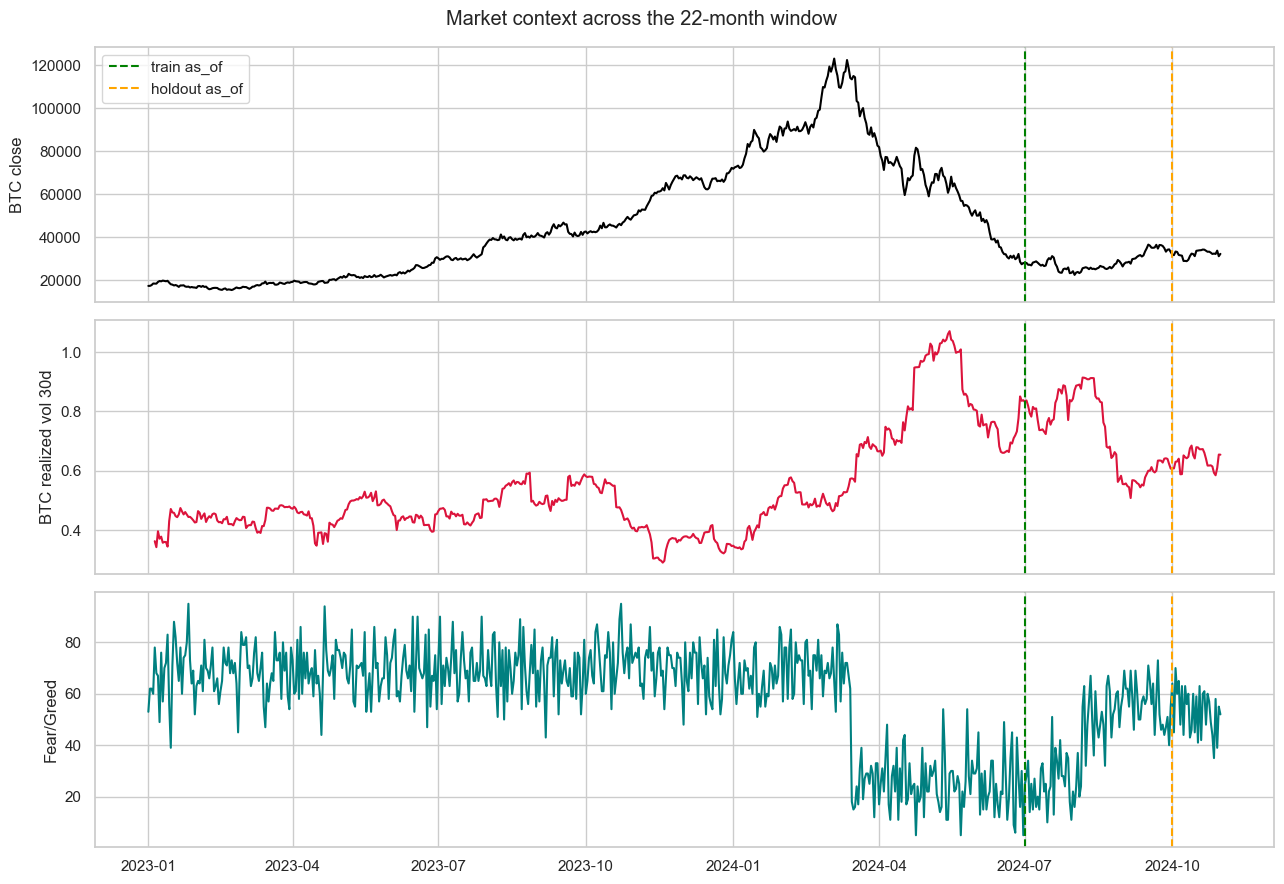

Market window: 2023-01-01 -> 2024-10-31
train    2024-07-01: btc=27595  vol=0.8319  fng=25
holdout  2024-10-01: btc=31832  vol=0.6089  fng=64


In [5]:
train_date = labels['as_of_date'].iloc[0]
hold_date = holdout['as_of_date'].iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
axes[0].plot(market['date'], market['btc_close'], color='black')
axes[0].set_ylabel('BTC close')
axes[1].plot(market['date'], market['btc_realized_vol_30d'], color='crimson')
axes[1].set_ylabel('BTC realized vol 30d')
axes[2].plot(market['date'], market['fear_greed_index'], color='teal')
axes[2].set_ylabel('Fear/Greed')
for ax in axes:
    ax.axvline(train_date, color='green', ls='--', lw=1.5, label='train as_of')
    ax.axvline(hold_date, color='orange', ls='--', lw=1.5, label='holdout as_of')
axes[0].legend(loc='upper left')
fig.suptitle('Market context across the 22-month window')
fig.tight_layout()
plt.show()

print('Market window:', market['date'].min().date(), '->', market['date'].max().date())
for d, tag in [(train_date, 'train'), (hold_date, 'holdout')]:
    row = market.loc[market['date'] == d]
    if not row.empty:
        r = row.iloc[0]
        print(f"{tag:8s} {d.date()}: btc={r['btc_close']:.0f}  vol={r['btc_realized_vol_30d']}  fng={r['fear_greed_index']}")

## 1.6 Categorical distributions & signal P&L

In [6]:
cat_cols = ['acquisition_channel', 'region', 'plan_variant', 'payment_method',
            'age_bracket', 'signup_device', 'had_trial', 'initial_discord_join']
for c in cat_cols:
    if c in members.columns:
        print(f'--- {c} ---')
        print(members[c].value_counts(dropna=False))
        print()

--- acquisition_channel ---
acquisition_channel
youtube_organic         129
twitter_paid             56
exchange_partnership     42
referral                 33
podcast                  30
other                    10
Name: count, dtype: int64

--- region ---
region
EU       100
NA        77
APAC      56
LATAM     29
MENA      28
OTHER     10
Name: count, dtype: int64

--- plan_variant ---
plan_variant
monthly_basic        137
monthly_premium      117
quarterly_premium     46
Name: count, dtype: int64

--- payment_method ---
payment_method
stripe_card    186
crypto_usdc     52
paypal          36
crypto_btc      26
Name: count, dtype: int64

--- age_bracket ---
age_bracket
25-34    128
35-44     69
18-24     53
45-54     40
55+       10
Name: count, dtype: int64

--- signup_device ---
signup_device
mobile     169
desktop    124
tablet       7
Name: count, dtype: int64

--- had_trial ---
had_trial
1    163
0    137
Name: count, dtype: int64

--- initial_discord_join ---
initial_discord_joi

In [7]:
print('signals_taken - direction:')
print(signals['direction'].value_counts(dropna=False))
print('\nrealized_pnl_pct describe:')
print(signals['realized_pnl_pct'].describe())
print('\nrealized_pnl_usd describe:')
print(signals['realized_pnl_usd'].describe())

print('\nsupport tickets - category:')
print(tickets['category'].value_counts(dropna=False))
print('\nopen (unresolved) tickets:', tickets['resolved_at'].isna().sum())

signals_taken - direction:
direction
long     2895
short    1087
Name: count, dtype: int64

realized_pnl_pct describe:
count    3982.000000
mean        0.004980
std         0.090300
min        -0.318100
25%        -0.055875
50%         0.006300
75%         0.067800
max         0.323000
Name: realized_pnl_pct, dtype: float64

realized_pnl_usd describe:
count    3982.000000
mean       18.475665
std       312.547580
min     -1931.000000
25%       -62.950000
50%         6.700000
75%        80.800000
max      2212.000000
Name: realized_pnl_usd, dtype: float64

support tickets - category:
category
billing    214
trust      142
content    107
access      97
other       78
Name: count, dtype: int64

open (unresolved) tickets: 1


# Part 2 — Feature Engineering

## 2.1 `build_features()`

In [8]:
def build_features(member_ids, as_of_date):
    '''Point-in-time features for member_ids as of as_of_date.
    Uses ONLY data strictly before as_of_date (behavioral) / on-or-before (market). No leakage.'''
    as_of = pd.Timestamp(as_of_date)
    mids = pd.Index(pd.unique(pd.Series(member_ids)), name='member_id')
    feat = pd.DataFrame(index=mids)

    # ---------- market / regime scalars (same for everyone at this as_of) ----------
    def price_on_or_before(d):
        sub = market.loc[market['date'] <= d].sort_values('date')['btc_close']
        return sub.iloc[-1] if len(sub) else np.nan
    mk_hist = market.loc[market['date'] <= as_of].sort_values('date')
    last = mk_hist.iloc[-1]
    btc_now = last['btc_close']
    mkt = {
        'mkt_btc_close': btc_now,
        'mkt_btc_return_30d': btc_now / price_on_or_before(as_of - pd.Timedelta(days=30)) - 1,
        'mkt_btc_return_90d': btc_now / price_on_or_before(as_of - pd.Timedelta(days=90)) - 1,
        'mkt_realized_vol_30d': last['btc_realized_vol_30d'],
        'mkt_fear_greed': last['fear_greed_index'],
        'mkt_funding_rate': last['funding_rate_avg_8h'],
    }

    # ---------- profile (members.csv) ----------
    m = members.set_index('member_id').reindex(mids)
    feat['tenure_days'] = (as_of - m['signup_date']).dt.days
    feat['had_trial'] = m['had_trial']
    feat['initial_discord_join'] = m['initial_discord_join']
    feat['opted_in_newsletter'] = m['opted_in_newsletter']
    feat['lifetime_signal_count_at_signup'] = m['lifetime_signal_count_at_signup']
    feat['btc_price_vs_signup'] = btc_now / m['signup_btc_price'] - 1
    for c in ['acquisition_channel', 'region', 'plan_variant',
              'payment_method', 'age_bracket', 'signup_device']:
        feat[c] = m[c].astype('object')

    # ---------- engagement (engagement_events.csv) ----------
    ev = events[(events['timestamp_utc'] < as_of) & (events['member_id'].isin(mids))].copy()
    ev['days_ago'] = (as_of - ev['timestamp_utc']).dt.total_seconds() / 86400.0
    ev['w7'] = ev['days_ago'] < 7
    ev['w30'] = ev['days_ago'] < 30
    ev['w90'] = ev['days_ago'] < 90
    ev['w30_60'] = (ev['days_ago'] >= 30) & (ev['days_ago'] < 60)
    eg = ev.groupby('member_id')
    feat['days_since_last_event'] = eg['days_ago'].min()
    feat['events_total'] = eg.size()
    feat['events_7d'] = eg['w7'].sum()
    feat['events_30d'] = eg['w30'].sum()
    feat['events_90d'] = eg['w90'].sum()
    ev_prev30 = eg['w30_60'].sum()
    feat['engagement_trend'] = (feat['events_30d'] + 1) / (ev_prev30 + 1)
    feat['active_days_30d'] = (ev[ev['w30']].groupby('member_id')['timestamp_utc']
                               .apply(lambda s: s.dt.normalize().nunique()))
    feat['avg_session_sec'] = (ev[ev['w90'] & ev['session_duration_sec'].notna()]
                               .groupby('member_id')['session_duration_sec'].mean())
    type_counts = (ev[ev['w30']].groupby(['member_id', 'event_type']).size().unstack(fill_value=0))
    for et in ['stream_view', 'signal_view', 'signal_acted', 'discord_message', 'dashboard_login']:
        feat[f'evt_{et}_30d'] = type_counts[et] if et in type_counts.columns else 0

    # ---------- signals (signals_taken.csv) ----------
    sg = signals[(signals['taken_at'] < as_of) & (signals['member_id'].isin(mids))].copy()
    sg['days_ago'] = (as_of - sg['taken_at']).dt.total_seconds() / 86400.0
    sgg = sg.groupby('member_id')
    feat['signals_total'] = sgg.size()
    feat['days_since_last_signal'] = sgg['days_ago'].min()
    feat['signals_90d'] = sg[sg['days_ago'] < 90].groupby('member_id').size()
    feat['signal_cum_pnl_usd'] = sgg['realized_pnl_usd'].sum()
    feat['signal_avg_pnl_pct'] = sgg['realized_pnl_pct'].mean()
    feat['signal_win_rate'] = sgg['realized_pnl_pct'].apply(lambda s: (s > 0).mean())

    # ---------- tickets (support_tickets.csv) ----------
    tk = tickets[(tickets['opened_at'] < as_of) & (tickets['member_id'].isin(mids))].copy()
    tk['days_ago'] = (as_of - tk['opened_at']).dt.total_seconds() / 86400.0
    tk['open_at_asof'] = tk['resolved_at'].isna() | (tk['resolved_at'] >= as_of)
    tkg = tk.groupby('member_id')
    feat['tickets_total'] = tkg.size()
    feat['tickets_90d'] = tk[tk['days_ago'] < 90].groupby('member_id').size()
    feat['days_since_last_ticket'] = tkg['days_ago'].min()
    feat['open_tickets'] = tkg['open_at_asof'].sum()
    feat['has_trust_ticket'] = tkg['category'].apply(lambda s: (s == 'trust').any()).astype('float')
    feat['has_billing_ticket'] = tkg['category'].apply(lambda s: (s == 'billing').any()).astype('float')

    # ---------- missing-data flags (before fill) ----------
    feat['no_events'] = feat['events_total'].isna().astype(int)
    feat['no_signals'] = feat['signals_total'].isna().astype(int)
    feat['no_tickets'] = feat['tickets_total'].isna().astype(int)

    # ---------- fill NaNs (do this BEFORE interactions so products are clean) ----------
    NEVER = 3650.0  # 'never happened' recency sentinel (~10y)
    count_cols = (['events_total', 'events_7d', 'events_30d', 'events_90d', 'active_days_30d',
                   'signals_total', 'signals_90d', 'signal_cum_pnl_usd', 'tickets_total',
                   'tickets_90d', 'open_tickets']
                  + [c for c in feat.columns if c.startswith('evt_')])
    for c in count_cols:
        feat[c] = feat[c].fillna(0)
    for c in ['days_since_last_event', 'days_since_last_signal', 'days_since_last_ticket']:
        feat[c] = feat[c].fillna(NEVER)
    for c in ['signal_win_rate', 'signal_avg_pnl_pct', 'avg_session_sec',
              'has_trust_ticket', 'has_billing_ticket', 'engagement_trend']:
        feat[c] = feat[c].fillna(0)

    # ---------- broadcast market scalars + regime x behavior interactions ----------
    for k, v in mkt.items():
        feat[k] = v
    feat['vol_x_trend'] = feat['mkt_realized_vol_30d'] * feat['engagement_trend']
    feat['vol_x_events30'] = feat['mkt_realized_vol_30d'] * feat['events_30d']
    feat['ret90_x_events30'] = feat['mkt_btc_return_90d'] * feat['events_30d']

    feat.index.name = 'member_id'
    return feat.reset_index()

print('build_features defined.')

build_features defined.


## 2.2 Build train & holdout feature tables

In [9]:
train_features = build_features(labels['member_id'], train_date)
train_features = train_features.merge(labels[['member_id', 'churned']], on='member_id', how='left')
holdout_features = build_features(holdout['member_id'], hold_date)

n_feats = len([c for c in train_features.columns if c not in ('member_id', 'churned')])
print('train_features  :', train_features.shape, '| churn rate:', round(train_features['churned'].mean(), 3))
print('holdout_features:', holdout_features.shape)
print('n feature columns:', n_feats)
train_features.head()

train_features  : (119, 51) | churn rate: 0.151
holdout_features: (108, 50)
n feature columns: 49


,member_id,tenure_days,had_trial,initial_discord_join,opted_in_newsletter,lifetime_signal_count_at_signup,btc_price_vs_signup,acquisition_channel,region,plan_variant,payment_method,age_bracket,signup_device,days_since_last_event,events_total,events_7d,events_30d,events_90d,engagement_trend,active_days_30d,avg_session_sec,evt_stream_view_30d,evt_signal_view_30d,evt_signal_acted_30d,evt_discord_message_30d,evt_dashboard_login_30d,signals_total,days_since_last_signal,signals_90d,signal_cum_pnl_usd,signal_avg_pnl_pct,signal_win_rate,tickets_total,tickets_90d,days_since_last_ticket,open_tickets,has_trust_ticket,has_billing_ticket,no_events,no_signals,no_tickets,mkt_btc_close,mkt_btc_return_30d,mkt_btc_return_90d,mkt_realized_vol_30d,mkt_fear_greed,mkt_funding_rate,vol_x_trend,vol_x_events30,ret90_x_events30,churned
0,M10000,543,1,0,1,0,0.504198,twitter_paid,APAC,monthly_premium,stripe_card,35-44,desktop,0.211794,616.0,5.0,47.0,121.0,1.548387,24.0,357.931818,14.0,12.0,8.0,10.0,3.0,32.0,4.903472,10.0,1323.15,-0.000059,0.437500,2.0,0.0,357.885289,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,1.288103,39.0993,-30.324173,0
1,M10005,536,0,1,1,0,0.419457,youtube_organic,NA,monthly_premium,stripe_card,18-24,mobile,1.467546,1204.0,10.0,51.0,201.0,0.650000,26.0,387.792079,19.0,13.0,2.0,11.0,6.0,104.0,4.925000,30.0,-22.10,-0.001552,0.500000,13.0,1.0,15.040451,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.540735,42.4269,-32.904954,0
2,M10006,532,0,0,0,0,0.545140,referral,APAC,monthly_basic,paypal,25-34,desktop,1.319097,615.0,6.0,27.0,77.0,0.933333,18.0,408.904762,7.0,5.0,1.0,7.0,7.0,39.0,27.792361,6.0,6983.15,0.027156,0.589744,2.0,0.0,384.013981,0.0,0.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.776440,22.4613,-17.420270,0
3,M10010,525,0,1,1,0,0.570984,youtube_organic,LATAM,monthly_basic,stripe_card,35-44,tablet,0.659306,573.0,6.0,31.0,105.0,0.820513,18.0,462.434783,12.0,4.0,2.0,9.0,4.0,42.0,6.900000,8.0,1865.85,0.014671,0.547619,8.0,1.0,83.868704,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.682585,25.7889,-20.001050,0
4,M10013,516,1,1,0,0,0.607881,youtube_organic,MENA,monthly_premium,stripe_card,25-34,desktop,3.732662,210.0,1.0,11.0,42.0,0.923077,11.0,392.380952,1.0,3.0,1.0,0.0,6.0,10.0,6.795833,3.0,-43.30,0.018560,0.600000,2.0,0.0,171.511157,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.767908,9.1509,-7.097147,1


## 2.3 Missing-value rates

In [10]:
miss_t = (train_features.isna().mean() * 100).round(1)
miss_h = (holdout_features.isna().mean() * 100).round(1)
mtab = pd.DataFrame({'train_%null': miss_t, 'holdout_%null': miss_h})
mtab = mtab[mtab.max(axis=1) > 0].sort_values('train_%null', ascending=False)
print('Columns still containing nulls (after fills):')
mtab

Columns still containing nulls (after fills):


,train_%null,holdout_%null


## 2.4 Regime separation check

Confirm the market features differ between the two snapshots (regime baked in)

In [11]:
mkt_cols = [c for c in train_features.columns if c.startswith('mkt_')]
regime = pd.DataFrame({
    'train (2024-07-01)': train_features[mkt_cols].iloc[0],
    'holdout (2024-10-01)': holdout_features[mkt_cols].iloc[0],
})
print('Regime features per snapshot (constant within each set):')
print(regime.to_string())

Regime features per snapshot (constant within each set):
                      train (2024-07-01)  holdout (2024-10-01)
mkt_btc_close               27595.460000          31832.150000
mkt_btc_return_30d             -0.447580              0.154598
mkt_btc_return_90d             -0.645195              0.174532
mkt_realized_vol_30d            0.831900              0.608900
mkt_fear_greed                 25.000000             64.000000
mkt_funding_rate                0.000175              0.001096


## 2.5 One-hot encode categoricals

In [12]:
CAT_COLS = ['acquisition_channel', 'region', 'plan_variant',
            'payment_method', 'age_bracket', 'signup_device']

# Shared category sets (union across train+holdout) -> identical dummy columns in both
categories = {}
for c in CAT_COLS:
    vals = pd.concat([train_features[c], holdout_features[c]]).fillna('Missing').astype(str)
    categories[c] = sorted(vals.unique())

def one_hot_encode(df, cat_cols, categories):
    out = df.copy()
    for c in cat_cols:
        out[c] = pd.Categorical(out[c].fillna('Missing').astype(str), categories=categories[c])
    out = pd.get_dummies(out, columns=cat_cols, prefix=cat_cols)
    bool_cols = out.select_dtypes('bool').columns
    out[bool_cols] = out[bool_cols].astype('int8')
    return out

train_model = one_hot_encode(train_features, CAT_COLS, categories)
holdout_model = one_hot_encode(holdout_features, CAT_COLS, categories)

# Align: holdout gets exactly the train feature columns (excluding the label), same order
feature_cols = [c for c in train_model.columns if c != 'churned']
assert set(feature_cols) == set(holdout_model.columns), 'train/holdout feature columns differ!'
holdout_model = holdout_model[feature_cols]

print('encoded train_model  :', train_model.shape)
print('encoded holdout_model:', holdout_model.shape)
print('dummy columns added  :', sum(len(v) for v in categories.values()), 'from', len(CAT_COLS), 'categoricals')
print('columns aligned      :', feature_cols == list(holdout_model.columns))
print('any nulls left       : train', int(train_model.isna().sum().sum()), '| holdout', int(holdout_model.isna().sum().sum()))
train_model.head()

encoded train_model  : (119, 72)
encoded holdout_model: (108, 71)
dummy columns added  : 27 from 6 categoricals
columns aligned      : True
any nulls left       : train 0 | holdout 0


,member_id,tenure_days,had_trial,initial_discord_join,opted_in_newsletter,lifetime_signal_count_at_signup,btc_price_vs_signup,days_since_last_event,events_total,events_7d,events_30d,events_90d,engagement_trend,active_days_30d,avg_session_sec,evt_stream_view_30d,evt_signal_view_30d,evt_signal_acted_30d,evt_discord_message_30d,evt_dashboard_login_30d,signals_total,days_since_last_signal,signals_90d,signal_cum_pnl_usd,signal_avg_pnl_pct,signal_win_rate,tickets_total,tickets_90d,days_since_last_ticket,open_tickets,has_trust_ticket,has_billing_ticket,no_events,no_signals,no_tickets,mkt_btc_close,mkt_btc_return_30d,mkt_btc_return_90d,mkt_realized_vol_30d,mkt_fear_greed,mkt_funding_rate,vol_x_trend,vol_x_events30,ret90_x_events30,churned,acquisition_channel_exchange_partnership,acquisition_channel_other,acquisition_channel_podcast,acquisition_channel_referral,acquisition_channel_twitter_paid,acquisition_channel_youtube_organic,region_APAC,region_EU,region_LATAM,region_MENA,region_NA,region_OTHER,plan_variant_monthly_basic,plan_variant_monthly_premium,plan_variant_quarterly_premium,payment_method_crypto_btc,payment_method_crypto_usdc,payment_method_paypal,payment_method_stripe_card,age_bracket_18-24,age_bracket_25-34,age_bracket_35-44,age_bracket_45-54,age_bracket_55+,signup_device_desktop,signup_device_mobile,signup_device_tablet
0,M10000,543,1,0,1,0,0.504198,0.211794,616.0,5.0,47.0,121.0,1.548387,24.0,357.931818,14.0,12.0,8.0,10.0,3.0,32.0,4.903472,10.0,1323.15,-0.000059,0.437500,2.0,0.0,357.885289,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,1.288103,39.0993,-30.324173,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0
1,M10005,536,0,1,1,0,0.419457,1.467546,1204.0,10.0,51.0,201.0,0.650000,26.0,387.792079,19.0,13.0,2.0,11.0,6.0,104.0,4.925000,30.0,-22.10,-0.001552,0.500000,13.0,1.0,15.040451,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.540735,42.4269,-32.904954,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1,0
2,M10006,532,0,0,0,0,0.545140,1.319097,615.0,6.0,27.0,77.0,0.933333,18.0,408.904762,7.0,5.0,1.0,7.0,7.0,39.0,27.792361,6.0,6983.15,0.027156,0.589744,2.0,0.0,384.013981,0.0,0.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.776440,22.4613,-17.420270,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0
3,M10010,525,0,1,1,0,0.570984,0.659306,573.0,6.0,31.0,105.0,0.820513,18.0,462.434783,12.0,4.0,2.0,9.0,4.0,42.0,6.900000,8.0,1865.85,0.014671,0.547619,8.0,1.0,83.868704,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.682585,25.7889,-20.001050,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1
4,M10013,516,1,1,0,0,0.607881,3.732662,210.0,1.0,11.0,42.0,0.923077,11.0,392.380952,1.0,3.0,1.0,0.0,6.0,10.0,6.795833,3.0,-43.30,0.018560,0.600000,2.0,0.0,171.511157,0.0,1.0,1.0,0,0,0,27595.46,-0.44758,-0.645195,0.8319,25,0.000175,0.767908,9.1509,-7.097147,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0


## 2.6 Save feature tables

In [13]:
OUT = DATA_DIR / 'processed'
OUT.mkdir(parents=True, exist_ok=True)
# Save the encoded, model-ready tables as the feature CSVs (one-hot, columns aligned)
train_model.to_csv(OUT / 'train_features.csv', index=False)
holdout_model.to_csv(OUT / 'holdout_features.csv', index=False)
print('Saved to', OUT, ':')
print('  train_features.csv  ', train_model.shape)
print('  holdout_features.csv', holdout_model.shape)

Saved to F:\myWorks\python\regime-aware-churn-predictor\regime_aware_churn_predictor\data\processed :
  train_features.csv   (119, 72)
  holdout_features.csv (108, 71)
